In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv("Copy of raw_data.csv")

df.head()

,Name,Age,Salary,Join_Date,Department
0,Pam,25.0,70200.0,1/15/2023,HR
1,Jane,NaN,65000.0,8/1/2022,Finance
2,Alice,22.0,71350.0,5/20/2021,HR
3,Bob,22.0,NaN,1/15/2023,IT
4,Pam,25.0,71250.0,1/15/2023,HR


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        43 non-null     str    
 1   Age         39 non-null     float64
 2   Salary      36 non-null     float64
 3   Join_Date   43 non-null     str    
 4   Department  43 non-null     str    
dtypes: float64(2), str(3)
memory usage: 1.8 KB


In [7]:
df.isnull().sum()

Name          0
Age           4
Salary        7
Join_Date     0
Department    0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        43 non-null     str    
 1   Age         39 non-null     float64
 2   Salary      36 non-null     float64
 3   Join_Date   43 non-null     str    
 4   Department  43 non-null     str    
dtypes: float64(2), str(3)
memory usage: 1.8 KB


In [9]:
df.isnull().sum()

Name          0
Age           4
Salary        7
Join_Date     0
Department    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
df[df.duplicated()]

,Name,Age,Salary,Join_Date,Department
31,Sam,40.0,NaN,9/5/2022,IT


In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(42, 5)

In [17]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

In [18]:
df.isnull().sum()

Name          0
Age           0
Salary        0
Join_Date     0
Department    0
dtype: int64

In [19]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 55118.5
Upper Bound: 90802.5


In [20]:
outliers = df[
    (df["Salary"] < lower_bound) |
    (df["Salary"] > upper_bound)
]

outliers[["Name", "Salary", "Department"]]

,Name,Salary,Department
6,Joanne,120000.0,IT
15,Susy,126001.0,IT
18,Joanne,125600.0,IT
21,Norma,921000.0,IT
28,Jenny,801423.0,IT
42,Kim,546222.0,HR


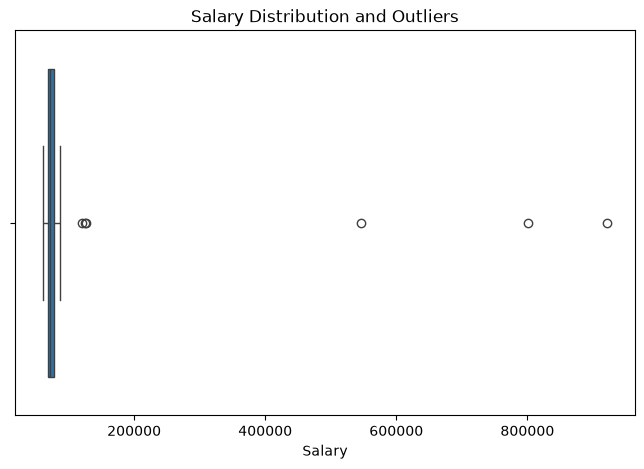

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Salary"])

plt.title("Salary Distribution and Outliers")
plt.xlabel("Salary")

plt.show()

In [22]:
df["Join_Date"] = pd.to_datetime(df["Join_Date"])

df["Join_Date"].head()

0   2023-01-15
1   2022-08-01
2   2021-05-20
3   2023-01-15
4   2023-01-15
Name: Join_Date, dtype: datetime64[us]

In [23]:
df["Department"].value_counts()

Department
HR         22
Finance    10
IT         10
Name: count, dtype: int64

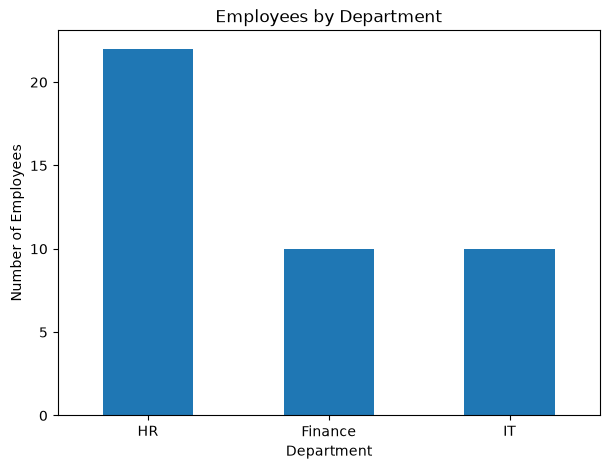

In [24]:
department_counts = df["Department"].value_counts()

plt.figure(figsize=(7, 5))
department_counts.plot(kind="bar")

plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.show()

In [25]:
avg_salary = df.groupby("Department")["Salary"].mean()

avg_salary

Department
Finance     65614.1
HR          95294.0
IT         245670.6
Name: Salary, dtype: float64

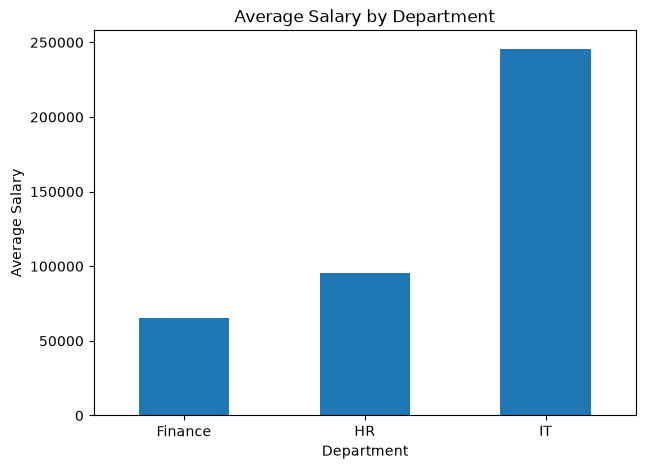

In [26]:
plt.figure(figsize=(7, 5))

avg_salary.plot(kind="bar")

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=0)

plt.show()

In [27]:
print("Rows and Columns:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Rows and Columns: (42, 5)

Missing Values:
Name          0
Age           0
Salary        0
Join_Date     0
Department    0
dtype: int64

Duplicate Rows: 0

Data Types:
Name                     str
Age                  float64
Salary               float64
Join_Date     datetime64[us]
Department               str
dtype: object


In [28]:
df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
